### Notebook for ML classification of Healthy/Acne Lesional/Acne Non-Lesional labels using V1-V3, V4, and metabolomics.
### Feature Comparison between V1-V3 and V4 primers for ML classification of skin class. 
### Compositional Tensor Factorization for longitudinal samples. 

Notebook author: Tyler Myers

In [1]:
import qiime2 as q2
from qiime2 import Artifact
from qiime2 import Metadata
import pandas as pd
import matplotlib.pyplot as plt
import os
from qiime2.plugins.gemelli.actions import ctf, rpca
from qiime2.plugins.emperor.visualizers import biplot, plot
from qiime2.plugins.feature_table.methods import filter_samples
from gemelli.preprocessing import matrix_rclr
from skbio.stats.composition import clr
from biom import load_table
%matplotlib inline

In [ ]:
v3_table_original = Artifact.load('../Data/16S/Tables/174950_rarefied_table.qza').view(pd.DataFrame)
v4_table_original = Artifact.load('../Data/16S/Tables/174951_rarefied_table.qza').view(pd.DataFrame)
metabolomics_table = load_table('../Data/metabolomics_table_final.biom').to_dataframe().T

metadata = pd.read_csv('../Metadata/metadata_final_22102024.tsv', sep='\t', index_col=0)
taxonomy = pd.read_csv('../Taxonomy/174116_taxonomy.tsv', sep='\t', index_col=0)

In [3]:
# Create H, AL, ANL labels based on cohort and category
metadata['label'] = metadata.apply(lambda x: 'H' if x['cohort'] == 'control' else ('AL' if x['cohort'] == 'acne' and x['category'] == 'acne' else ('ANL' if x['cohort'] == 'acne' and x['category'] == 'clear_zone' else None)), axis=1)
metadata['subject_c_zone'] = metadata.subject_randomization_id.astype(str) + '_' + metadata.c_zone.astype(str)

In [4]:
# Function to transform index by removing first two parts
def transform_index(idx):
    parts = idx.split('.')
    return '.'.join(parts[2:])

# Transform indices for metadata
metadata.index = metadata.index.map(transform_index)
# Drop duplicates in metadata (keeping first occurrence)
metadata = metadata.loc[~metadata.index.duplicated(keep='first')]
# metadata.to_csv('../data/metadata_processed.tsv', sep='\t', index=True)

# Transform indices for v3_table
v3_table_original.index = v3_table_original.index.map(transform_index)
# Drop duplicates in v3_table
v3_table_original = v3_table_original.loc[~v3_table_original.index.duplicated(keep='first')]

# Transform indices for v4_table
v4_table_original.index = v4_table_original.index.map(transform_index)
# Drop duplicates in v4_table
v4_table_original = v4_table_original.loc[~v4_table_original.index.duplicated(keep='first')]

# Verify the changes (optional)
print(f"Modified metadata shape: {metadata.shape}")
print(f"Modified v3_table shape: {v3_table_original.shape}")
print(f"Modified v4_table shape: {v4_table_original.shape}")

# Create a shared index between all tables
shared_samples = set(metadata.index).intersection(
    set(v3_table_original.index), 
    set(v4_table_original.index), 
    # set(metabolomics_table.index)
)
print(f"\nNumber of samples common to all tables: {len(shared_samples)}")

# Filter all tables to only include samples present in all datasets
metadata = metadata.loc[list(shared_samples)]
v3_table = v3_table_original.loc[list(shared_samples)]
v4_table = v4_table_original.loc[list(shared_samples)]
metabolomics_table = metabolomics_table.loc[metabolomics_table.index.isin(v4_table.index)]#metabolomics_table.loc[list(shared_samples)]

# Verify the filtered tables
print("\nAfter filtering to shared samples:")
print(f"Metadata shape: {metadata.shape}")
print(f"V3 table shape: {v3_table.shape}")
print(f"V4 table shape: {v4_table.shape}")
print(f"Metabolomics table shape: {metabolomics_table.shape}")

Modified metadata shape: (267, 96)
Modified v3_table shape: (250, 158)
Modified v4_table shape: (225, 218)

Number of samples common to all tables: 197

After filtering to shared samples:
Metadata shape: (197, 96)
V3 table shape: (197, 158)
V4 table shape: (197, 218)
Metabolomics table shape: (148, 1142)


In [5]:
# Create a dictionary mapping Feature IDs to their taxonomic classifications
asv_to_taxonomy = taxonomy['Taxon'].to_dict()

# Function to process tables - rename columns and combine those with same taxonomy
def process_table(table):
    # Create a copy to avoid modifying the original
    df = table.copy()
    
    # Dictionary to track columns with the same taxonomy
    taxonomy_groups = {}
    
    # Rename columns using taxonomy information
    for col in df.columns:
        if col in asv_to_taxonomy:
            tax_name = asv_to_taxonomy[col]
            if tax_name in taxonomy_groups:
                taxonomy_groups[tax_name].append(col)
            else:
                taxonomy_groups[tax_name] = [col]
        else:
            # If no taxonomy match found, keep original column name
            taxonomy_groups[f"Unknown_{col[:10]}"] = [col]
    
    # Create a new DataFrame with combined columns
    result_df = pd.DataFrame(index=df.index)
    
    # Combine columns with the same taxonomy by summing their values
    for tax_name, columns in taxonomy_groups.items():
        result_df[tax_name] = df[columns].sum(axis=1)
    
    return result_df

# Process both tables
v3_table_taxonomy = process_table(v3_table)
v4_table_taxonomy = process_table(v4_table)

# Print shapes for verification
print(f"Original v3_table shape: {v3_table.shape}")
print(f"Processed v3_table shape: {v3_table_taxonomy.shape}")
print(f"Original v4_table shape: {v4_table.shape}")
print(f"Processed v4_table shape: {v4_table_taxonomy.shape}")

Original v3_table shape: (197, 158)
Processed v3_table shape: (197, 91)
Original v4_table shape: (197, 218)
Processed v4_table shape: (197, 135)


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_4119/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[tax_name] = df[columns].sum(axis=1)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_4119/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[tax_name] = df[columns].sum(axis=1)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_4119/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

### Random Forest Classification AUC-ROC for H/AL/ANL for each data type ( on the ASV level for 16S)

In [6]:
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_curve, auc, RocCurveDisplay
# from sklearn.model_selection import GroupKFold
# from sklearn.preprocessing import label_binarize
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# from scipy import interp
# warnings.filterwarnings('ignore')

# # Set overall styling for plots
# plt.style.use('seaborn-whitegrid')
# sns.set_context("paper", font_scale=1.5)
# sns.set_style("ticks")

# # Function to run group-stratified cross-validation with feature importance
# def run_group_cv(X, y, groups, n_splits=5):
#     # Initialize group k-fold
#     gkf = GroupKFold(n_splits=n_splits)
    
#     # Initialize arrays to store results
#     cv_results = []
#     feature_importances = pd.DataFrame(index=X.columns)
    
#     # Run cross-validation
#     for i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
#         X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
#         # Handle cases where train set might contain only one class
#         if len(np.unique(y_train)) < 2:
#             continue
            
#         # Train classifier
#         clf = RandomForestClassifier(n_estimators=1000, random_state=42)
#         clf.fit(X_train, y_train)
        
#         # Predict probabilities
#         probas = clf.predict_proba(X_test)
        
#         # Store feature importance for this fold
#         feature_importances[f'fold_{i}'] = clf.feature_importances_
        
#         # Store results
#         fpr, tpr, _ = roc_curve(y_test, probas[:, 1])
#         roc_auc = auc(fpr, tpr)
#         cv_results.append({
#             'y_true': y_test,
#             'y_proba': probas[:, 1],
#             'fpr': fpr,
#             'tpr': tpr,
#             'auc': roc_auc
#         })
    
#     # Calculate mean feature importance across folds
#     feature_importances['mean_importance'] = feature_importances.mean(axis=1)
#     feature_importances['std_importance'] = feature_importances.std(axis=1)
#     feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
#     return cv_results, feature_importances

# # Function to compute and plot ROC curves with error bars
# def plot_roc_curves_with_errors(tables_dict, metadata, pair_comparisons, n_splits=5):
#     num_tables = len(tables_dict)
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
#     # Dictionary to store feature importances
#     all_feature_importances = {}
    
#     # For each pairwise comparison
#     for i, (label1, label2) in enumerate(pair_comparisons):
#         ax = axs[i]
        
#         # Plot title
#         ax.set_title(f'{label1} vs {label2}', fontsize=16)
#         comparison_key = f'{label1}_vs_{label2}'
#         all_feature_importances[comparison_key] = {}
        
#         # For each data table
#         for table_name, table in tables_dict.items():
#             # Get samples with either label1 or label2
#             meta_subset = metadata[metadata['label'].isin([label1, label2])]
            
#             # Get data table samples that match the metadata subset
#             common_samples = table.index.intersection(meta_subset.index)
#             X = table.loc[common_samples]
#             meta_filtered = meta_subset.loc[common_samples]
            
#             # Skip if insufficient samples
#             if len(common_samples) < 10:
#                 print(f"Skipping {table_name} for {label1} vs {label2}: insufficient samples ({len(common_samples)})")
#                 continue
                
#             # Create binary labels (0 for label1, 1 for label2)
#             y = meta_filtered['label'].map({label1: 0, label2: 1})
            
#             # Get subject IDs for grouping
#             groups = meta_filtered['host_subject_id']
            
#             # Run CV
#             cv_results, feature_imp = run_group_cv(X, y, groups, n_splits=n_splits)
            
#             # Store feature importance
#             all_feature_importances[comparison_key][table_name] = feature_imp
            
#             # Skip if not enough results
#             if len(cv_results) < 2:
#                 print(f"Skipping {table_name} for {label1} vs {label2}: CV returned insufficient results")
#                 continue
            
#             # Interpolate all ROC curves to a common set of FPR points
#             mean_fpr = np.linspace(0, 1, 100)
#             tprs = []
#             aucs = []
            
#             for result in cv_results:
#                 tprs.append(interp(mean_fpr, result['fpr'], result['tpr']))
#                 tprs[-1][0] = 0.0
#                 aucs.append(result['auc'])
            
#             # Calculate mean and std of TPR
#             mean_tpr = np.mean(tprs, axis=0)
#             mean_tpr[-1] = 1.0
#             mean_auc = np.mean(aucs)
#             std_auc = np.std(aucs)
#             std_tpr = np.std(tprs, axis=0)
            
#             # Calculate upper and lower bounds for shaded region
#             tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
#             tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
#             # Plot mean ROC curve
#             ax.plot(mean_fpr, mean_tpr, lw=2, 
#                    label=f'{table_name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
            
#             # Plot shaded region for error bars
#             ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.3)
        
#         # Add diagonal line
#         ax.plot([0, 1], [0, 1], 'k--', lw=1)
        
#         # Customize plot
#         ax.set_xlabel('False Positive Rate', fontsize=14)
#         if i == 0:
#             ax.set_ylabel('True Positive Rate', fontsize=14)
#         ax.set_xlim([0.0, 1.0])
#         ax.set_ylim([0.0, 1.05])
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.grid(True, linestyle='--', alpha=0.7)
        
#         # Add legend for each subplot
#         ax.legend(loc='lower right', fontsize=10)
    
#     # Adjust layout
#     plt.tight_layout()
    
#     return fig, all_feature_importances

# # Create a dictionary of tables
# tables = {
#     'V1-V3': v3_table_taxonomy,
#     'V4': v4_table_taxonomy,
#     'Metabolomics': metabolomics_table
# }

# # Define pairwise comparisons
# comparisons = [('H', 'AL'), ('H', 'ANL'), ('AL', 'ANL')]

# # Set number of CV splits
# n_cv_splits = 5

# # Run analysis and plot
# fig, feature_importances = plot_roc_curves_with_errors(tables, metadata, comparisons, n_splits=n_cv_splits)

# # Save figure if desired
# # fig.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')

# plt.show()

# # Display the top 10 most important features for each comparison and data type
# for comparison, data_types in feature_importances.items():
#     print(f"\n{'='*50}")
#     print(f"Top 10 important features for {comparison}:")
#     print(f"{'='*50}")
    
#     for data_type, features_df in data_types.items():
#         print(f"\n{data_type}:")
#         print("-" * 40)
#         top_features = features_df.sort_values('mean_importance', ascending=False).head(10)
#         print(top_features[['mean_importance', 'std_importance']])

# # Return feature importance dataframes for downstream analysis
# feature_importances

Skipping fold 1 due to insufficient class representation
Skipping fold 1 due to insufficient class representation
Skipping fold 2 due to insufficient class representation

Pairwise Performance Comparison of Methods
     Task Method 1     Method 2  Mean AUC 1  Mean AUC 2  AUC Difference  p-value (Wilcoxon)  p-value (t-test)  Significant (p<0.05)
  H_vs_AL    V1-V3           V4      0.7105      0.8465         -0.1360              0.5000            0.0891                 False
  H_vs_AL    V1-V3 Metabolomics      0.7105      0.7188         -0.0083              1.0000            0.7847                 False
  H_vs_AL       V4 Metabolomics      0.8465      0.7188          0.1277              0.5000            0.0219                 False
 H_vs_ANL    V1-V3           V4      0.7366      0.6915          0.0451              1.0000            0.6205                 False
 H_vs_ANL    V1-V3 Metabolomics      0.7366      0.5047          0.2319              0.2500            0.0494                

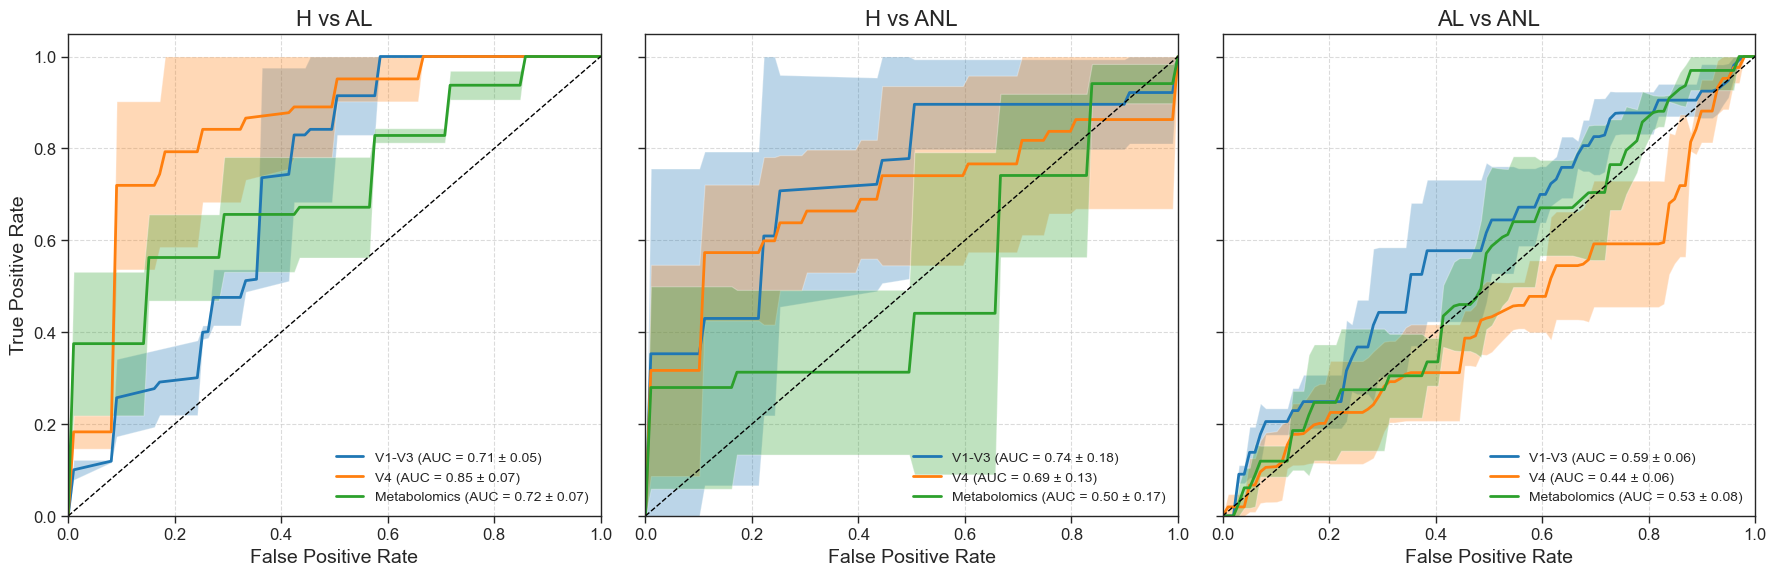

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import interp
from scipy.stats import wilcoxon, ttest_rel
import pandas as pd
from itertools import combinations
warnings.filterwarnings('ignore')

# Set overall styling for plots
plt.style.use('seaborn-whitegrid')
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")

# Custom function for group-stratified k-fold
def group_stratified_kfold(X, y, groups, n_splits=5, random_state=42):
    """
    Custom implementation of cross-validation that respects both groups and stratification
    
    Parameters:
    -----------
    X : DataFrame
        Feature matrix
    y : Series
        Target labels
    groups : Series
        Group labels for samples (e.g., host_subject_id)
    n_splits : int
        Number of folds
    random_state : int
        Random seed
    
    Returns:
    --------
    list of tuples
        Each tuple contains (train_indices, test_indices)
    """
    # Get unique groups
    unique_groups = np.unique(groups)
    np.random.seed(random_state)
    np.random.shuffle(unique_groups)
    
    # Create label distribution per group
    group_label_dist = {}
    for group in unique_groups:
        group_mask = groups == group
        group_y = y[group_mask]
        group_label_dist[group] = {label: np.sum(group_y == label) for label in np.unique(y)}
    
    # Initialize folds with empty lists
    folds = [[] for _ in range(n_splits)]
    
    # Track current distribution of labels in each fold
    fold_label_dist = [{label: 0 for label in np.unique(y)} for _ in range(n_splits)]
    
    # Sort groups by size (number of samples) in descending order to place larger groups first
    sorted_groups = sorted(unique_groups, key=lambda g: sum(groups == g), reverse=True)
    
    # Assign groups to folds
    for group in sorted_groups:
        # Calculate which fold would benefit most from this group
        # by minimizing the imbalance across all labels
        best_fold = 0
        min_imbalance = float('inf')
        
        group_size = sum(groups == group)
        
        for fold_idx in range(n_splits):
            # Calculate current imbalance if we add this group
            temp_fold_dist = fold_label_dist[fold_idx].copy()
            for label, count in group_label_dist[group].items():
                temp_fold_dist[label] += count
            
            # Calculate imbalance as variance of label proportions
            fold_size = sum(temp_fold_dist.values())
            if fold_size == 0:
                proportions = [0] * len(temp_fold_dist)
            else:
                proportions = [count / fold_size for count in temp_fold_dist.values()]
            
            imbalance = np.var(proportions) + fold_size / (sum(groups.shape) / n_splits)
            
            if imbalance < min_imbalance:
                min_imbalance = imbalance
                best_fold = fold_idx
        
        # Assign group to best fold
        folds[best_fold].extend(np.where(groups == group)[0])
        # Update fold distribution
        for label, count in group_label_dist[group].items():
            fold_label_dist[best_fold][label] += count
    
    # Create train/test indices
    train_test_indices = []
    for i in range(n_splits):
        test_idx = np.array(folds[i])
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        train_test_indices.append((train_idx, test_idx))
    
    return train_test_indices

# Modified function to run group-stratified cross-validation with feature importance
def run_group_stratified_cv(X, y, groups, n_splits=5):
    # Get group-stratified folds
    folds = group_stratified_kfold(X, y, groups, n_splits=n_splits)
    
    # Initialize arrays to store results
    cv_results = []
    feature_importances = pd.DataFrame(index=X.columns)
    fold_aucs = []
    
    # Run cross-validation
    for i, (train_idx, test_idx) in enumerate(folds):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Handle cases where train set might contain only one class
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping fold {i+1} due to insufficient class representation")
            continue
            
        # Train classifier
        clf = RandomForestClassifier(n_estimators=1000, random_state=42)
        clf.fit(X_train, y_train)
        
        # Predict probabilities
        probas = clf.predict_proba(X_test)
        
        # Store feature importance for this fold
        feature_importances[f'fold_{i}'] = clf.feature_importances_
        
        # Store results
        fpr, tpr, _ = roc_curve(y_test, probas[:, 1])
        roc_auc = auc(fpr, tpr)
        fold_aucs.append(roc_auc)
        
        cv_results.append({
            'y_true': y_test,
            'y_proba': probas[:, 1],
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'fold': i
        })
    
    # Calculate mean feature importance across folds
    feature_importances['mean_importance'] = feature_importances.mean(axis=1)
    feature_importances['std_importance'] = feature_importances.std(axis=1)
    feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
    return cv_results, feature_importances, fold_aucs

# Function to compute and plot ROC curves with error bars plus perform pairwise comparisons
def plot_roc_curves_with_comparisons(tables_dict, metadata, pair_comparisons, n_splits=5):
    num_tables = len(tables_dict)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    # Dictionary to store feature importances and AUCs for each method
    all_feature_importances = {}
    all_fold_aucs = {}
    
    # For each pairwise comparison
    for i, (label1, label2) in enumerate(pair_comparisons):
        ax = axs[i]
        
        # Plot title
        ax.set_title(f'{label1} vs {label2}', fontsize=16)
        comparison_key = f'{label1}_vs_{label2}'
        all_feature_importances[comparison_key] = {}
        all_fold_aucs[comparison_key] = {}
        
        # For each data table
        for table_name, table in tables_dict.items():
            # Get samples with either label1 or label2
            meta_subset = metadata[metadata['label'].isin([label1, label2])]
            
            # Get data table samples that match the metadata subset
            common_samples = table.index.intersection(meta_subset.index)
            X = table.loc[common_samples]
            meta_filtered = meta_subset.loc[common_samples]
            
            # Skip if insufficient samples
            if len(common_samples) < 10:
                print(f"Skipping {table_name} for {label1} vs {label2}: insufficient samples ({len(common_samples)})")
                continue
                
            # Create binary labels (0 for label1, 1 for label2)
            y = meta_filtered['label'].map({label1: 0, label2: 1})
            
            # Get subject IDs for grouping
            groups = meta_filtered['host_subject_id']
            
            # Run CV with group stratification
            cv_results, feature_imp, fold_aucs = run_group_stratified_cv(X, y, groups, n_splits=n_splits)
            
            # Store results
            all_feature_importances[comparison_key][table_name] = feature_imp
            all_fold_aucs[comparison_key][table_name] = fold_aucs
            
            # Skip if not enough results
            if len(cv_results) < 2:
                print(f"Skipping {table_name} for {label1} vs {label2}: CV returned insufficient results")
                continue
            
            # Interpolate all ROC curves to a common set of FPR points
            mean_fpr = np.linspace(0, 1, 100)
            tprs = []
            aucs = []
            
            for result in cv_results:
                tprs.append(interp(mean_fpr, result['fpr'], result['tpr']))
                tprs[-1][0] = 0.0
                aucs.append(result['auc'])
            
            # Calculate mean and std of TPR
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            std_tpr = np.std(tprs, axis=0)
            
            # Calculate upper and lower bounds for shaded region
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
            # Plot mean ROC curve
            ax.plot(mean_fpr, mean_tpr, lw=2, 
                   label=f'{table_name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
            
            # Plot shaded region for error bars
            ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.3)
        
        # Add diagonal line
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        
        # Customize plot
        ax.set_xlabel('False Positive Rate', fontsize=14)
        if i == 0:
            ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add legend for each subplot
        ax.legend(loc='lower right', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Perform pairwise statistical tests on fold AUCs
    pairwise_comparisons = compute_pairwise_comparisons(all_fold_aucs)
    
    return fig, all_feature_importances, pairwise_comparisons

# Function to perform pairwise statistical tests
def compute_pairwise_comparisons(fold_aucs_dict):
    """
    Perform pairwise statistical tests between methods for each task
    
    Parameters:
    -----------
    fold_aucs_dict : dict
        Dictionary with fold-wise AUC values for each method
    
    Returns:
    --------
    DataFrame
        Table with pairwise comparisons and p-values
    """
    results = []
    
    for task, methods_dict in fold_aucs_dict.items():
        # Get list of methods that have AUC values
        methods = list(methods_dict.keys())
        
        # Perform pairwise comparisons
        for method1, method2 in combinations(methods, 2):
            # Get AUC values for both methods
            aucs1 = methods_dict[method1]
            aucs2 = methods_dict[method2]
            
            # Ensure equal length (use only common folds)
            min_len = min(len(aucs1), len(aucs2))
            if min_len < 2:
                continue
                
            aucs1 = aucs1[:min_len]
            aucs2 = aucs2[:min_len]
            
            # Calculate mean AUCs
            mean_auc1 = np.mean(aucs1)
            mean_auc2 = np.mean(aucs2)
            diff_auc = mean_auc1 - mean_auc2
            
            # Perform statistical tests
            # Wilcoxon signed-rank test (non-parametric)
            try:
                _, p_wilcoxon = wilcoxon(aucs1, aucs2)
            except:
                p_wilcoxon = np.nan
                
            # Paired t-test (parametric)
            _, p_ttest = ttest_rel(aucs1, aucs2)
            
            # Store results
            results.append({
                'Task': task,
                'Method 1': method1,
                'Method 2': method2,
                'Mean AUC 1': mean_auc1,
                'Mean AUC 2': mean_auc2,
                'AUC Difference': diff_auc,
                'p-value (Wilcoxon)': p_wilcoxon,
                'p-value (t-test)': p_ttest,
                'Significant (p<0.05)': (p_wilcoxon < 0.05) if not np.isnan(p_wilcoxon) else (p_ttest < 0.05)
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

# Create a dictionary of tables
tables = {
    'V1-V3': v3_table_taxonomy,
    'V4': v4_table_taxonomy,
    'Metabolomics': metabolomics_table
}

# Define pairwise comparisons
comparisons = [('H', 'AL'), ('H', 'ANL'), ('AL', 'ANL')]

# Set number of CV splits
n_cv_splits = 3

# Run analysis and plot
fig, feature_importances, pairwise_stats = plot_roc_curves_with_comparisons(tables, metadata, comparisons, n_splits=n_cv_splits)

# Display pairwise performance comparison table
print("\n" + "="*80)
print("Pairwise Performance Comparison of Methods")
print("="*80)
print(pairwise_stats.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Display the top 10 most important features for each comparison and data type
for comparison, data_types in feature_importances.items():
    print(f"\n{'='*50}")
    print(f"Top 10 important features for {comparison}:")
    print(f"{'='*50}")
    
    for data_type, features_df in data_types.items():
        print(f"\n{data_type}:")
        print("-" * 40)
        top_features = features_df.sort_values('mean_importance', ascending=False).head(10)
        print(top_features[['mean_importance', 'std_importance']])

plt.show()

### Map features to taxonomy for 16S, and then compare between primer sets. 


Analyzing H vs AL classification
Number of overlapping features for H vs AL: 44


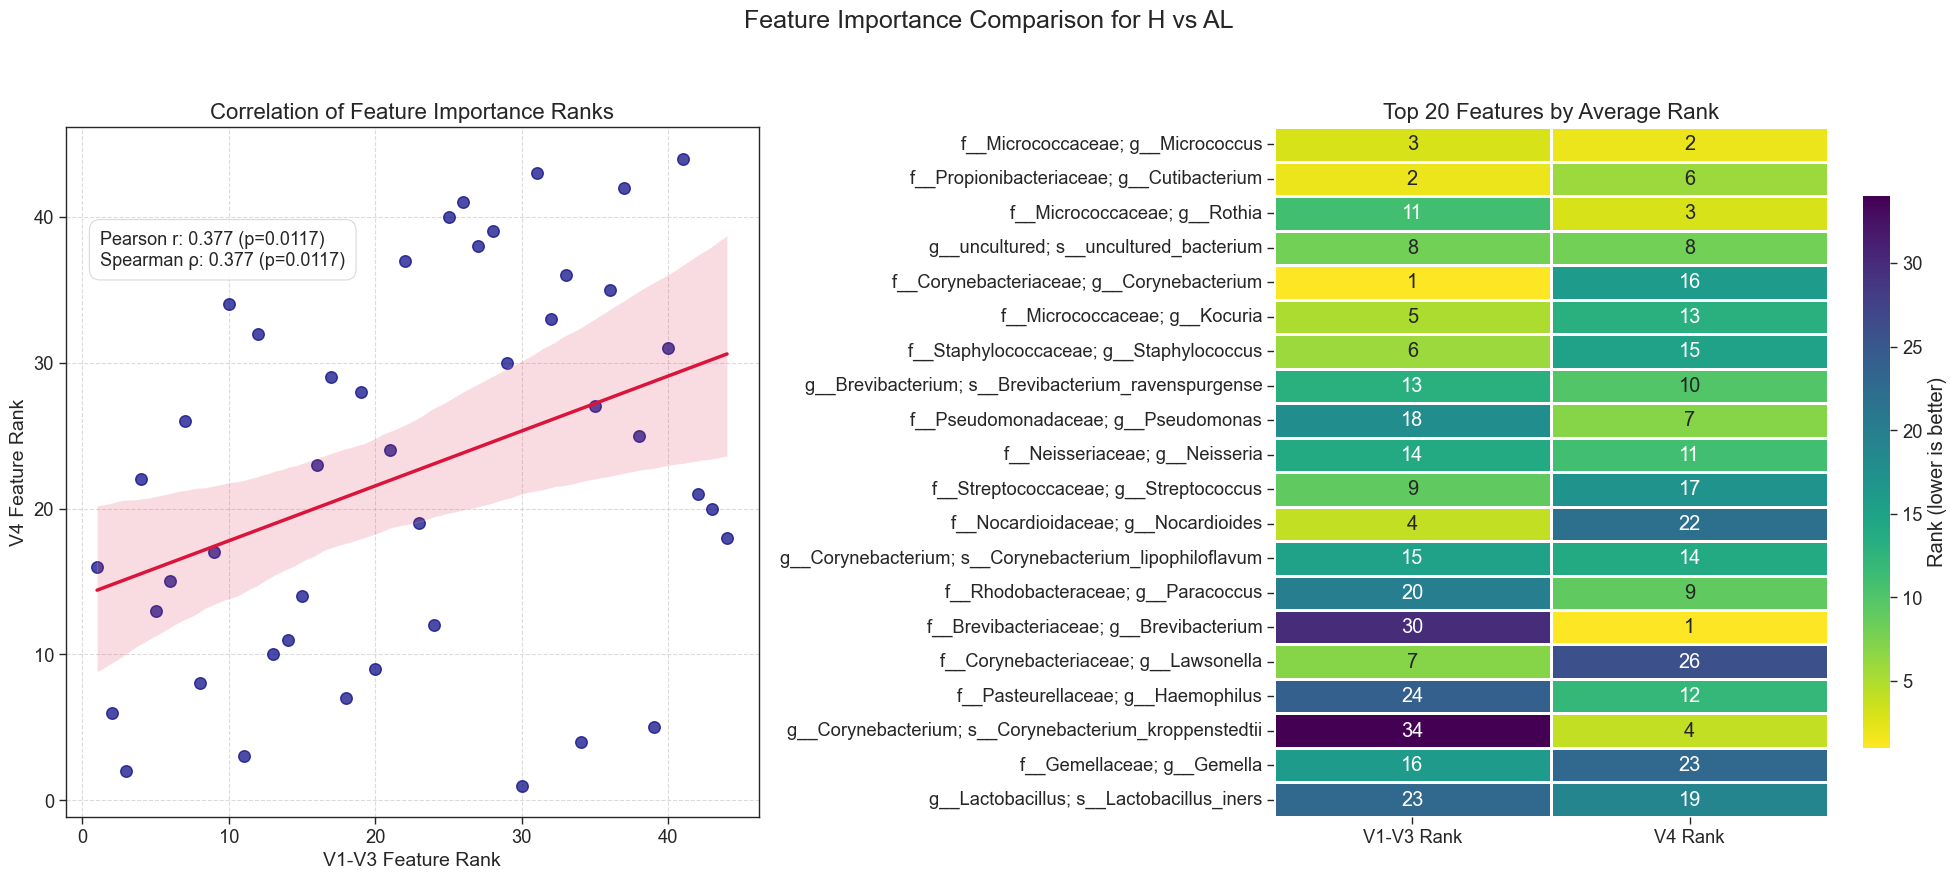


Analyzing H vs ANL classification
Number of overlapping features for H vs ANL: 44


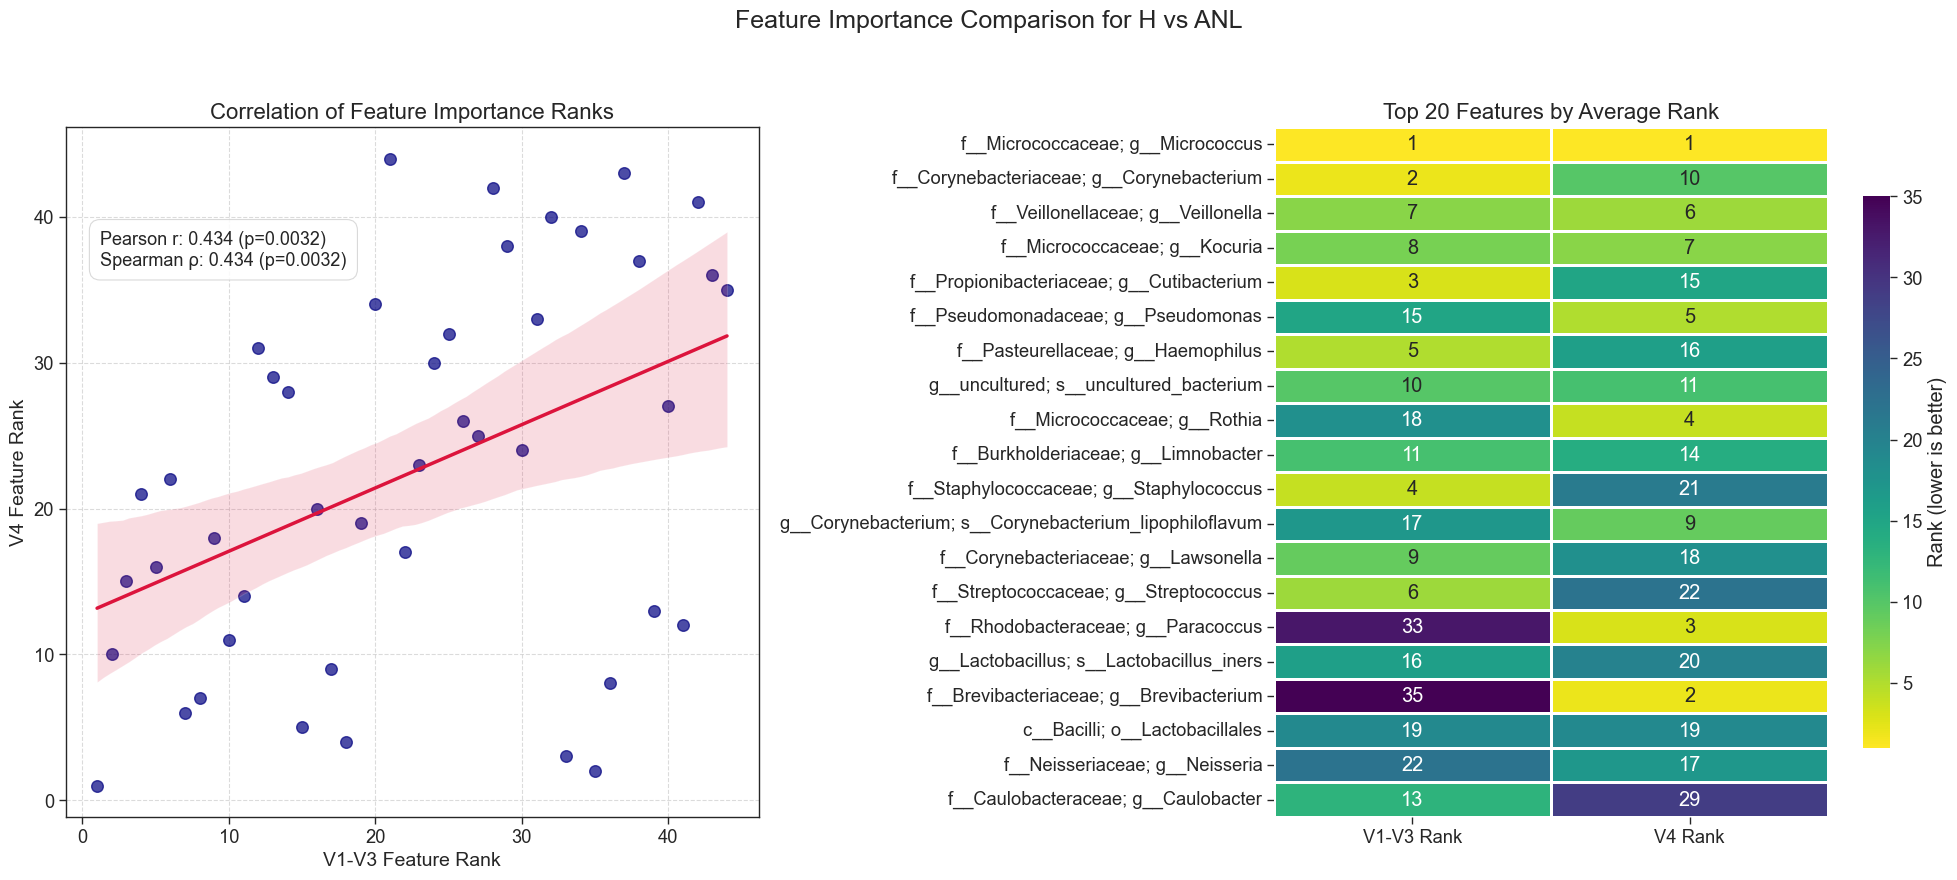


Analyzing AL vs ANL classification
Number of overlapping features for AL vs ANL: 44


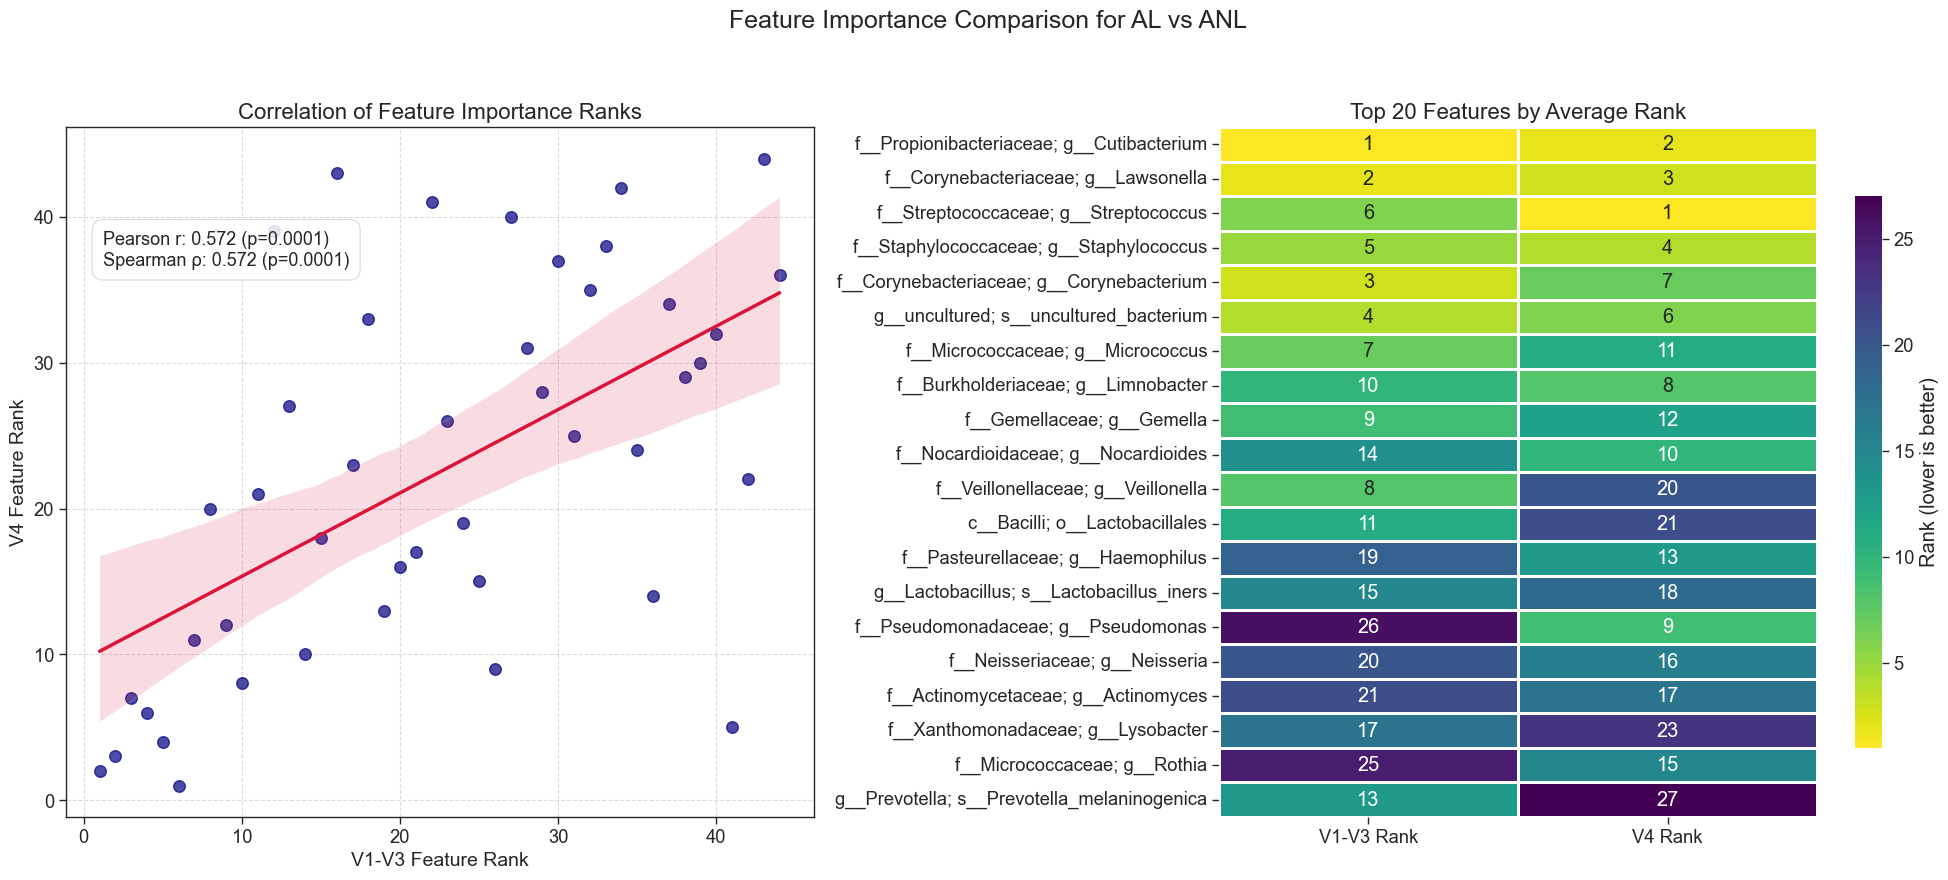

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

def compare_feature_importances(feature_imp_dict, task, top_n=20):
    """
    Creates improved comparison visualizations between V1-V3 and V4 feature importances
    using ranks for correlation analysis
    
    Parameters:
    -----------
    feature_imp_dict : dict
        Dictionary containing feature importance results
    task : str
        Classification task (e.g., 'H_vs_AL')
    top_n : int
        Number of top features to show in heatmap
    """
    # Format task name for display
    display_task = task.replace('_', ' ')
    
    # Extract feature importances for V1-V3 and V4
    v1v3_imp = feature_imp_dict[task]['V1-V3']
    v4_imp = feature_imp_dict[task]['V4']
    
    # Find overlapping features first
    common_features = set(v1v3_imp.index).intersection(set(v4_imp.index))
    print(f"Number of overlapping features for {display_task}: {len(common_features)}")
    
    # Filter for only overlapping features
    v1v3_filtered = v1v3_imp.loc[v1v3_imp.index.isin(common_features)]
    v4_filtered = v4_imp.loc[v4_imp.index.isin(common_features)]
    
    # Create DataFrames with feature importance values for overlapping features
    v1v3_df = pd.DataFrame({
        'feature': v1v3_filtered.index,
        'importance': v1v3_filtered['mean_importance']
    }).sort_values('importance', ascending=False)
    
    v4_df = pd.DataFrame({
        'feature': v4_filtered.index,
        'importance': v4_filtered['mean_importance']
    }).sort_values('importance', ascending=False)
    
    # Add rank information
    v1v3_df['rank'] = range(1, len(v1v3_df) + 1)
    v4_df['rank'] = range(1, len(v4_df) + 1)
    
    # Merge data for comparison
    merged_df = pd.merge(
        v1v3_df, v4_df,
        on='feature',
        suffixes=('_v1v3', '_v4')
    )
    
    # Calculate correlations based on ranks (not raw importance)
    pearson_r, p_pearson = pearsonr(merged_df['rank_v1v3'], merged_df['rank_v4'])
    spearman_r, p_spearman = spearmanr(merged_df['rank_v1v3'], merged_df['rank_v4'])
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(f"Feature Importance Comparison for {display_task}", fontsize=18, y=0.98)
    
    # 1. Regression plot using ranks
    sns.regplot(
        x='rank_v1v3', 
        y='rank_v4',
        data=merged_df,
        scatter_kws={'alpha': 0.7, 's': 70, 'color': 'navy'},
        line_kws={'color': 'crimson', 'lw': 2.5},
        ax=ax1
    )
    
    # Add correlation text - moved down and away from edge
    ax1.text(
        0.05, 0.80,
        f"Pearson r: {pearson_r:.3f} (p={p_pearson:.4f})\n"
        f"Spearman ρ: {spearman_r:.3f} (p={p_spearman:.4f})",
        transform=ax1.transAxes,
        fontsize=13,
        bbox=dict(facecolor='white', alpha=0.85, boxstyle='round,pad=0.6', edgecolor='lightgray')
    )
    
    ax1.set_title("Correlation of Feature Importance Ranks", fontsize=16)
    ax1.set_xlabel("V1-V3 Feature Rank", fontsize=14)
    ax1.set_ylabel("V4 Feature Rank", fontsize=14)
    
    # Make axes start from origin
    xlim = ax1.get_xlim()
    ylim = ax1.get_ylim()
    min_val = min(xlim[0], ylim[0])
    max_val = max(xlim[1], ylim[1])
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    
    # Add grid lines
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Heatmap of top feature ranks
    # Calculate average rank for selecting top features
    merged_df['avg_rank'] = (merged_df['rank_v1v3'] + merged_df['rank_v4']) / 2
    top_features = merged_df.sort_values('avg_rank').head(top_n)
    
    # Create rank comparison dataframe for heatmap
    heatmap_data = pd.DataFrame({
        'V1-V3 Rank': top_features['rank_v1v3'].values,
        'V4 Rank': top_features['rank_v4'].values
    }, index=top_features['feature'])
    
    # Simplify taxonomy names for better display
    simplified_names = []
    for feature in heatmap_data.index:
        # Extract most specific taxonomic level
        parts = feature.split('; ')
        if len(parts) > 1:
            # Get the most specific levels with actual taxonomic information
            filtered_parts = [p for p in parts if any(p.startswith(prefix) for prefix in 
                                                    ['p__', 'c__', 'o__', 'f__', 'g__', 's__'])]
            if len(filtered_parts) >= 2:
                simplified = '; '.join(filtered_parts[-2:])
            elif len(filtered_parts) == 1:
                simplified = filtered_parts[0]
            else:
                simplified = parts[-1]
            simplified_names.append(simplified)
        else:
            simplified_names.append(feature)
    
    heatmap_data.index = simplified_names
    
    # Plot heatmap with improved formatting
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.0f',
        cmap='viridis_r',  # Changed colormap
        linewidths=0.8,
        ax=ax2,
        cbar_kws={'label': 'Rank (lower is better)', 'shrink': 0.8}
    )
    
    ax2.set_title(f"Top {top_n} Features by Average Rank", fontsize=16)
    ax2.tick_params(axis='y', rotation=0)  # Improved y-axis tick readability
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for the suptitle
    plt.show()
    
    return merged_df

# Run comparisons for all three classification tasks
tasks = ['H_vs_AL', 'H_vs_ANL', 'AL_vs_ANL']
comparison_results = {}

for task in tasks:
    print(f"\n{'='*60}\nAnalyzing {task.replace('_', ' ')} classification\n{'='*60}")
    if task in feature_importances and 'V1-V3' in feature_importances[task] and 'V4' in feature_importances[task]:
        comparison_results[task] = compare_feature_importances(feature_importances, task)
    else:
        print(f"Missing data for task {task}")